#**1.- Explicación del conjunto de datos elegido cuál es su temática, su tamaño, con qué campos se relaciona y por qué puede resultar interesante**

He elegido un conjunto de datos que recoge información sobre turismo en diferentes paises (https://www.kaggle.com/datasets/imtkaggleteam/tourism).

He elegido este dataset porque me parece un tema interesante y tenía varios csv referentes al tema que podía utilizar para elegir los dos necesarios para realizar la tarea.

Entre todos ellos he elegido `11- number-of-people-employed-in-food-and-beverage-serving-activities-per-1000-population.csv` y `4- international-tourist-trips.csv`. Uno indica el número de población que trabaja en la restauración por cada 1000 habitantes y el otro indica la llegada de turismo por país. Me parecen dos conjuntos de datos interesantes y que se pueden relacionar para ver como afecta el turismo en el número de empleos destinados a la restauración.

He planteado hacer la tarea con otros varios datasets diferentes que me interesaban más temáticamente pero o no tenían un conjunto de datos suficientemente grande para hacer un análisis interesante o solamente tenían un csv, lo cual no cumplia los requisitos de la práctica.

#**2.- Explicación de cómo se cargan los datos al servdor: por url (manera preferente), por medio de un API o si facilitas los archivos de la entrega**

Yo voy a cargar los ficheros a través de una librería propia de Kaggle llamada `kagglehub`. En la ficha de este dataset te indica que puedes descargarlo con esta librería que ya está añadida por defecto en google colab. Una vez descargados utilizaré la ruta donde se almacenan y el nombre de los csv que utilizaré (hay varios) para cargar los dataframe que voy a utilizar.

De esta forma simplemente ejecutando el código se podrán cargar los datos sin necesidad de subir manualmente los ficheros a cargar.

In [ ]:
# Importamos las librerías a utilizar durante toda la práctica
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from sklearn.preprocessing import StandardScaler
from json.decoder import JSONDecodeError
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor

In [ ]:
# Descargo de Kaggle el dataset que me interesa
path = kagglehub.dataset_download("imtkaggleteam/tourism")

# Utilizando la ruta devuelta inicializo los dos dataframe que voy a utilizar en la práctica
df_employed = pd.read_csv(path + "/11- number-of-people-employed-in-food-and-beverage-serving-activities-per-1000-population.csv")
df_tourist = pd.read_csv(path + "/4- international-tourist-trips.csv")

100%|██████████| 790k/790k [00:00<00:00, 20.5MB/s]

Extracting files...


# 3.- Perfilado de datos, qué visualizaciones has usado y porqué, cómo facilitan la comprensión de los datos.

Lo primero que voy a hacer en el perfilado de datos es sobre el dataset principal es ver que tipos de datos tiene a través de `df_tourist.info()` y de las primeras muestras del dataframe.

##3.1.- Perfilado de datos sobre el DataSet de turistas

In [ ]:
df_tourist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4940 entries, 0 to 4939
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Entity                       4940 non-null   object 
 1   Code                         4940 non-null   object 
 2   Year                         4940 non-null   int64  
 3   Inbound arrivals (tourists)  4940 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 154.5+ KB


In [ ]:
df_tourist.head()

,Entity,Code,Year,Inbound arrivals (tourists)
0,Albania,ALB,2007,1062000.0
1,Albania,ALB,2008,1247000.0
2,Albania,ALB,2009,1711000.0
3,Albania,ALB,2010,2191000.0
4,Albania,ALB,2011,2469000.0


Como podemos ver, el dataframe `df_tourist` contiene información por país y año del número de turistas que ha llegado al país. Esto lo representa mediante 4 columnas que son:

*   Entity: Nos indica el nombre del país al que hace referencia la entrada
*   Code: Representa el código del país mediante 3 letras.
*   Year: Representa el año al que corresponde el número de turistas
*   Inbound arrivals (tourist): Indica el número de turistas que han visitado el país ese año.

También podemos comprobar que el dataset tiene 4940 entradas, y ninguno de los datos es nulo, pues todas las columnas tienen valor en todas las entradas. Esto nos indica que el dataset parece tener buenos datos y que probablemente no haya que modificar mucho su contenido en el siguiente punto.

Para ver que los datos también tienen sentido voy a mostrar en una gráfica el progreso de turistas en España, lo cual debería ser creciente y nos permitiría detectar si hay algo raro o tiene buena pinta.

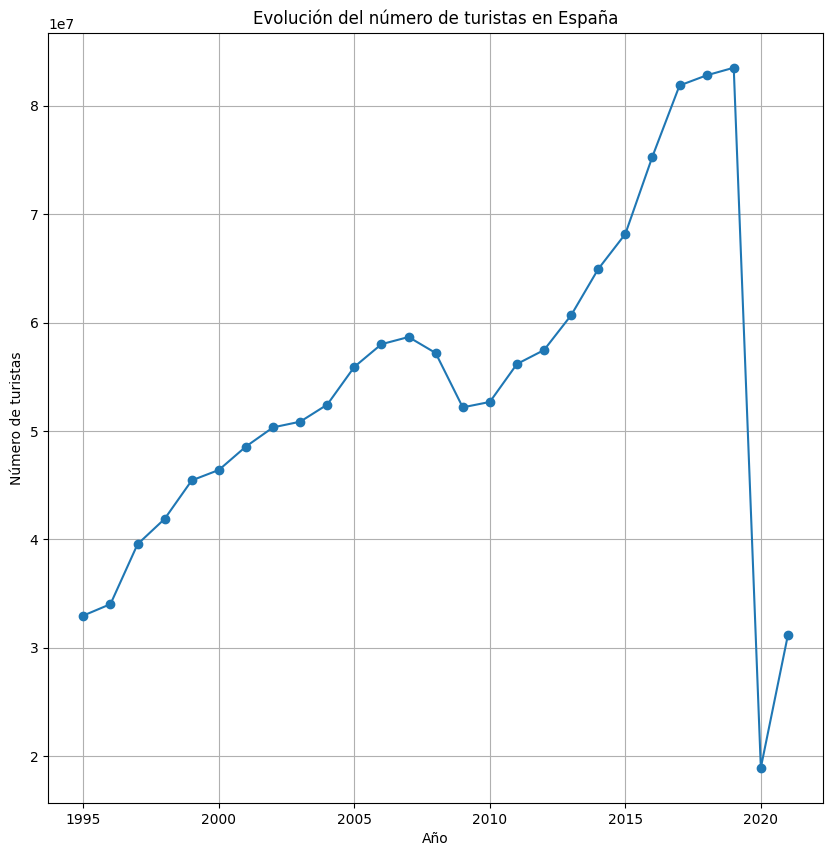

In [ ]:
# Inicializo un dataset con los datos esclusivos de España
spain_tourist_data = df_tourist[df_tourist['Entity'] == 'Spain']

# Creo un gráfico de líneas
plt.figure(figsize=(10, 10))
plt.plot(spain_tourist_data['Year'], spain_tourist_data['Inbound arrivals (tourists)'], marker='o')

# Añado títulos y etiquetas al gráfico
plt.title("Evolución del número de turistas en España")
plt.xlabel("Año")
plt.ylabel("Número de turistas")
plt.grid(True)

# Muestro el gráfico
plt.show()

Vemos que como predecíamos el data set tiene buena pinta, y muestra una gráfica creciente en cuanto a turistas en España a lo largo del tiempo. Vemos en 2008 - 2009 un pequeño bajón, probablemente dado por la crisis lo cual tiene sentido. Y otro bajón mucho más pronunciado en 2019 que analizaremos más adelante cuando tratemos con los datos, pero que tendrá sentido aunque parezca que no, pues fue el año de la pandemia y estuvo prohibido viajar.

##3.2.- Perfilado de datos sobre el DataSet de empleados en hostelería
Ahora vamos a hacer un pequeño análisis también sobre nuestro segundo dataframe siguiendo la mísma tónica que en el anterior.

In [ ]:
df_employed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 4 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Entity                                                             1045 non-null   object 
 1   Code                                                               1045 non-null   object 
 2   Year                                                               1045 non-null   int64  
 3   Employment (food and beverage serving activities) per 1000 people  1045 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 32.8+ KB


In [ ]:
df_employed.head()

,Entity,Code,Year,Employment (food and beverage serving activities) per 1000 people
0,Angola,AGO,2007,1.708873
1,Angola,AGO,2008,2.238432
2,Angola,AGO,2009,2.413088
3,Angola,AGO,2010,2.393705
4,Angola,AGO,2011,2.526555


Vemos que este DataSet tiene una pinta similar al anterior, en el nos describe el número de empleados que trabajan en la hostelería cada año por cada mil habitantes en cada país. Tiene 4 columnas para reflejar la información:

*   Entity: Indica el nombre del país al que hace referencia la entrada
*   Code: Representa el código del país mediante 3 dígitos
*   Year: Indica el año al que pertenecen los datos
*   Employment (food and bevarage serving activities) per 1000 people: Indica el número de personas que trabajan en la hostelería por cada 1000.

Al igual que con el anterior vemos que tiene muy buena pinta, tiene 1045 entradas y todas ellas tienen valor en todas sus columnas. También podemos ir viendo que hay varias columnas que nos permitirían juntar los dataset en puntos siguientes.

Voy a mostrar varias gráficas para ver la relación y evolución entre los trabajadores en hostelería y los años.
Voy a utilizar un mapa de calor para la correlación, un histograma para los empleados en hostelería y un diagrama de caja para detectar años anómalos.



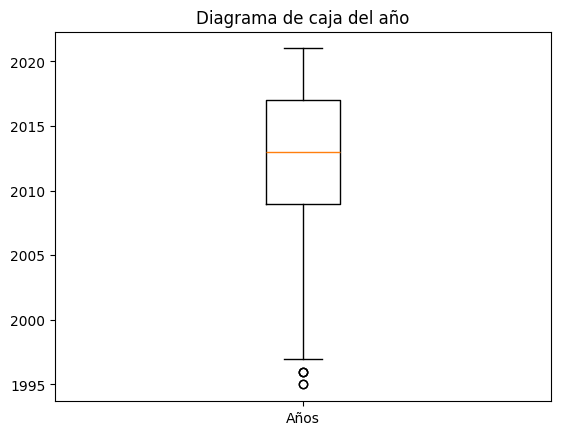

In [ ]:
# Definimos el diagrama de caja para la columna año
plt.boxplot([df_employed['Year']])
plt.title("Diagrama de caja del año")
plt.xticks([1], ['Años'])
plt.show()

<Axes: >

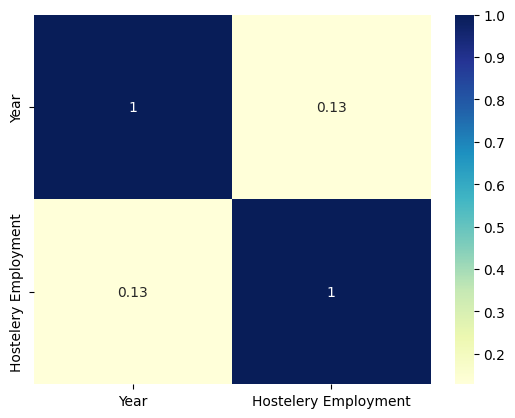

In [ ]:
# Obtenemos un dataframe con los datos numéricos
numerical_df = df_employed.select_dtypes(include=['number'])
# Renombro la columna de los empleados, porque al ser tan largo el nombre el gráfico se verá muy mal
numerical_df = numerical_df.rename(columns={'Employment (food and beverage serving activities) per 1000 people': 'Hostelery Employment'})
# Pintamos el mapa de color a partir de nuestro df numérico
sns.heatmap(numerical_df.corr(), annot=True, cmap='YlGnBu')

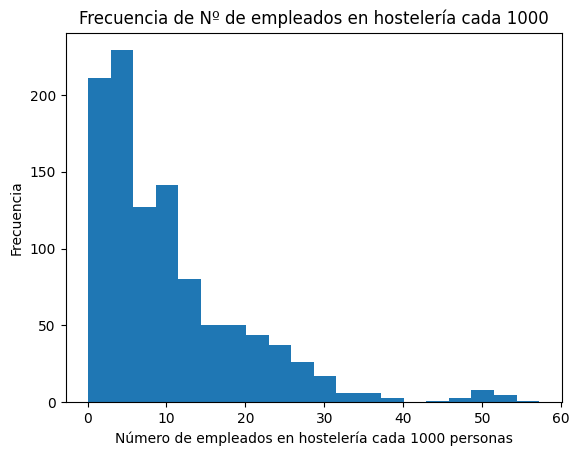

In [ ]:
# Inicializamos un histograma a partir de la columna de empleados en hostelería
plt.hist(df_employed['Employment (food and beverage serving activities) per 1000 people'], bins=20)
plt.xlabel("Número de empleados en hostelería cada 1000 personas")
plt.ylabel("Frecuencia")
plt.title("Frecuencia de Nº de empleados en hostelería cada 1000")
plt.show()

Gracias a estos gráficos vemos varios datos interesantes:


*   **Diagrama de caja:** El diagrama de caja de los años nos muestra, que aunque todos los dátos son válidos, pues el rango es lógico (1995-2020) la mayoría de datos se concentran entre los años 2010 y 2017. Vemos que hay muy pocos datos que se registran en en el siglo XX pues nos los dá como atípicos aunque son válidos.
*   **Mapa de calor:** Nos muestra que la correlación entre los años y los trabajadores en hostelería es muy baja, casi nula, pues su correlación es de 0.13.
*   **Histograma:** Vemos que la mayoría de entradas comprenden una frecuencia entre 0 y 10, pues es donde se concentran la mayoría de datos. El resto de entradas según el porcentaje de trabajadores en hostelería es más alto, tienen menos frecuencia en el dataset.



#4.- Normalización de datos

Dado que en nuestros data set solamente tenemos dos columnas numéricas, la normalización va a ser sencilla.

Normalizamos los datos porque cada escala numérica es diferente, lo que implica que las magnitudes al ser tan dispares pueden ocasionar que los modelos den más peso a unas que a otras.

Por ejemplo, en nuestro dataset hablamos de millones de turistas al año. Si enfrentamos estos datos el año que variará entre finales del siglo XX y principios del XXI, se daría un peso extremadamente grande al número de turistas en lugar de al año.

##4.1.- Normalización datos turistas
Primero veremos que los datos no están normalizados

In [ ]:
df_tourist[['Year', 'Inbound arrivals (tourists)']].head()

,Year,Inbound arrivals (tourists)
0,2007,1062000.0
1,2008,1247000.0
2,2009,1711000.0
3,2010,2191000.0
4,2011,2469000.0


Como podemos ver estamos asociando el año 2007 a el número de turistas 1062000, la escala es 500 veces mayor, por lo cual los años tendrían un peso ínfimo respecto a los turistas, así que procedemos a normalizarlos

In [ ]:
# Seleccionamos las columnas que vamos a estandarizar
tourist_columns_to_standarize = ['Year', 'Inbound arrivals (tourists)']

# Inicializamos el Scaler y agregamos las columnas que queremos escalar
scaler_tourist = StandardScaler()
scaler_tourist.fit(df_tourist[tourist_columns_to_standarize])

# Aplicamos la transformación sobre las columnas y creamos otro nuevo data frame con estas columnas escaladas
tourist_scaled_data = scaler_tourist.transform(df_tourist[tourist_columns_to_standarize])
tourist_scaled_df = pd.DataFrame(tourist_scaled_data, columns=tourist_columns_to_standarize)

Una vez estandarizados los datos vamos a ver que contiene el data frame nuevo y veremos son datos en la misma escala, que es lo que buscábamos.

In [ ]:
tourist_scaled_df.head()

,Year,Inbound arrivals (tourists)
0,-0.110839,-0.309087
1,0.019529,-0.291567
2,0.149896,-0.247624
3,0.280264,-0.202165
4,0.410632,-0.175837


Esta vez si vemos que están normalizado y tienen una escala similar. Ahora no tendremos una diferencia del año 2017 por ejemplo frente a 1062000, si no "juegan en la misma liga".

##4.2.- Normalización datos trabajadores en hostelería
Como hemos hecho antes, comprobamos que los datos no están normalizados

In [ ]:
df_employed[['Year', 'Employment (food and beverage serving activities) per 1000 people']].head()

,Year,Employment (food and beverage serving activities) per 1000 people
0,2007,1.708873
1,2008,2.238432
2,2009,2.413088
3,2010,2.393705
4,2011,2.526555


Y en efecto como ya sabíamos no están normalizados, cada uno tiene su escala, pues en el caso de los trabajadores, como su columna indica es la media frente a mil, ya por defecto, en un hipotético caso de que el 100% de personas en un país trabajasen en la hostelería, el valor medio sería como máximo 1000, lo cual es inferior al valor inferior que nos encontraremos en los años.

Por ello, procedemos a escalarlos igual que antes

In [ ]:
# Seleccionamos las columnas que vamos a estandarizar
employed_columns_to_standarize = ['Year', 'Employment (food and beverage serving activities) per 1000 people']

# Inicializamos el Scaler y agregamos las columnas que queremos escalar
scaler_employed = StandardScaler()
scaler_employed.fit(df_employed[employed_columns_to_standarize])

# Aplicamos la transformación sobre las columnas y creamos otro nuevo data frame con estas columnas escaladas
employed_scaled_data = scaler_employed.transform(df_employed[employed_columns_to_standarize])
employed_scaled_df = pd.DataFrame(employed_scaled_data, columns=employed_columns_to_standarize)

Una vez normalizados los datos, voy a ver los datos del nuevo data frame para confirmar que se han escalado correctamente.

In [ ]:
employed_scaled_df.head()

,Year,Employment (food and beverage serving activities) per 1000 people
0,-0.989505,-0.914167
1,-0.809203,-0.858981
2,-0.628901,-0.840780
3,-0.448598,-0.842800
4,-0.268296,-0.828956


Y en efecto, confirmamos que ahora los datos están normalizados y en la misma escala, lo cual nos servirá para tener un modelo más preciso y que de el mismo valor a una columna que a otra.

#5.- Validación de datos
En este punto vamos a validar que todos los datos del dataset son correctos y no hay datos erróneos. Aunque previsiblemente hemos visto en la apartado de perfilado que tiene buena pinta, vamos a confirmarlo en este punto.

##5.1.- Validación de datos de turistas
Lo primero que voy a hacer es mostar el valor mínimo y máximo de ambas columnas numéricas para ver si tiene sentido. En caso de que no lo tenga, decidiré que hacer con los datos inválidos.

In [ ]:
print("- Valor máximo de la columna Year: " + str(df_tourist['Year'].max()))
print("- Valor mínimo de la columna Year: " + str(df_tourist['Year'].min()))

print("- Valor máximo de la columna Inbound arrivals (tourists): " + str(df_tourist['Inbound arrivals (tourists)'].max()))
print("- Valor mínimo de la columna Inbound arrivals (tourists): " + str(df_tourist['Inbound arrivals (tourists)'].min()))

- Valor máximo de la columna Year: 2021
- Valor mínimo de la columna Year: 1995
- Valor máximo de la columna Inbound arrivals (tourists): 90914000.0
- Valor mínimo de la columna Inbound arrivals (tourists): 1.0


Vemos que la columna referente al año tiene sentido, pues por lo que se muestra estamos trabajando en un rango comprendido entre 1995 y 2021, años totalmente razonables para el estudio.

Sin embargo vemos que la columna tourist tiene valores más atípicos, pues aunque el máximo pueda tener sentido (90 millones de turistas) el mínimo es extraño, solamente es 1.

Dado que el COVID causó una pandemia que paralizó los viajes en todo el mundo, vamos a investigar un poco más este caso para ver si es un dato inválido, o simplemente es un dato atípico.

In [ ]:
df_tourist[df_tourist['Inbound arrivals (tourists)'] < 1000]

,Entity,Code,Year,Inbound arrivals (tourists)
37,American Samoa,ASM,2020,900.0
536,Bhutan,BTN,2021,1.0
2315,Kiribati,KIR,2021,70.0
2769,Marshall Islands,MHL,2021,35.0
3313,Niue,NIU,2021,200.0
4192,Solomon Islands,SLB,2021,700.0
4500,Tonga,TON,2021,200.0
4621,Tuvalu,TUV,1995,900.0
4646,Tuvalu,TUV,2020,600.0
4647,Tuvalu,TUV,2021,40.0


He filtrado todos las entradas que indiquen que hubo menos de 1000 turistas en un año. El país que según nuestro DataSet solo tuvo un visitante en todo el año es Bhutan, y viendo el resto de registros no muestra datos tan bajos, podemos considerar que es un dato inválido.

Dado que tenemos casi 5000 registros y solo 6 entradas con menos de 500 turistas, voy a proceder a eliminar estas entradas porque es muy probable que no tengan sentido. Dado el ínfimo número de entradas y la magnitud de este campo, es más anecdótica la eliminación porque no influiría apenas en el modelo, aun así creo que lo correcto es eliminarlos.

In [ ]:
df_tourist = df_tourist[df_tourist['Inbound arrivals (tourists)'] > 500]
df_tourist

,Entity,Code,Year,Inbound arrivals (tourists)
0,Albania,ALB,2007,1062000.0
1,Albania,ALB,2008,1247000.0
2,Albania,ALB,2009,1711000.0
3,Albania,ALB,2010,2191000.0
4,Albania,ALB,2011,2469000.0
...,...,...,...,...
4935,Zimbabwe,ZWE,1997,1281000.0
4936,Zimbabwe,ZWE,1998,1986000.0
4937,Zimbabwe,ZWE,1999,2101000.0
4938,Zimbabwe,ZWE,2000,1868000.0


Vemos como ahora se ha reducido a 4934 filas totales, en lugar de 4940 como había al principio, por lo que verificamos que se han eliminado las 6 que he considerado como inválidas.

##5.2.- Validación de datos de trabajadores en hostelería
En este caso vamos a proceder como hemos hecho en el punto anterior, primero mostraremos el valor menor y mayor de ambas columnas numéricas y valoraremos si hay datos inválidos o no en función del resultado.

In [ ]:
print("- Valor máximo de la columna Year: " + str(df_tourist['Year'].max()))
print("- Valor mínimo de la columna Year: " + str(df_tourist['Year'].min()))

print("- Número de empleados en hostelería máximo cada 1000 habitantes: " + str(df_employed['Employment (food and beverage serving activities) per 1000 people'].max()))
print("- Número de empleados en hostelería mínimo cada 1000 habitantes: " + str(df_employed['Employment (food and beverage serving activities) per 1000 people'].min()))

- Valor máximo de la columna Year: 2021
- Valor mínimo de la columna Year: 1995
- Número de empleados en hostelería máximo cada 1000 habitantes: 57.200447
- Número de empleados en hostelería mínimo cada 1000 habitantes: 0.08202572


Como con el dataset anterior, vemos que los datos del año tienen sentidos, pues están comprendidos entre 1995 y 2021, que son años lógicos y además el rango coincide con el dataset de turistas, por lo que este campo consideramos que es válido en su totalidad y no es necesario tratarlo.

Sin embargo vemos que en el número de trabajadores en la hostelería es desde 8 cada 100000 hasta 57 cada 1000. A mi me resulta extraño el valor mínimo, aunque al máximo le veo sentido, pero dado que desconozco si estos datos tienen o no sentido, voy a darlos por válidos de momento para estudiarlo más a fondo en la sección de detección de anomalías. Creo que tendré que hacer un estudio de la distribución de los datos entre sus cuartiles o percentiles para decidir si son valores válidos, o son valores erróneos.



#6.- Integración y eriquecimiento de los datos

Para enriquecer los datos, lo que voy a hacer es ir a buscar a Wikipedia la bandera de cada pais. Así cada entrada tendrá un nuevo campo que contendrá un enlace donde está almacenada la imagen de la bandera de su país.

Esto agrega un valor añadido para cualquiera que quiera utilizar el dataset, pues podría acceder rápidamente a cada bandera de cada país.

In [ ]:
# Inicializo un diccionario para almacenar la bandera de cada país,
# de modo que si la he obtenido ya, no necesite volver a realizar
# la consulta al api de la Wikipdia para optimizar el código
pais_bandera = {}

# Defino una función para enriquecer los datos
def enriquecer_datos_paises(fila):
    # Obtengo el nombre del pais
    pais = fila.Entity

    #Si la bandera está en el diccionario la obtengo de ahí
    if pais in pais_bandera:
        bandera = pais_bandera[pais]
        print(f"Se obtiene la bandera de {pais} del diccionario: {bandera}")
    else:
        # Realizo la consulta a la API de Wikipedia
        url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{pais}"

        # Agregamos el User-agent a la petición que vamos a realizar
        headers = {'User-agent': 'Mozilla/5.0' }
        respuesta = requests.get(url, headers=headers)

        # Si la respuesta tiene éxito deserializamos el contenido del json
        if respuesta.ok:
            try:
                # Deserializamos el json a un objeto
                datos_pais = respuesta.json()
                # Obtenemos la url de la bandera del pais
                bandera = datos_pais.get('originalimage', '').get('source', '')
                print(f"Llamada a Wikipedia: - {pais} -> {bandera}")
            except JSONDecodeError:
                # Si hay un error al deserializar la respuesta de Wikipedia lo indico
                print(f"Error al deserializar el json del pais: '{pais}'. Estado: {respuesta.status_code}, Respuesta: {respuesta.text[:200]}...")
                bandera = ''
            except Exception as e:
                # Capturo y muestro cualquier otro error y lo pinto
                print(f"Ha ocurrido un error desconocido al obtener la bandera de {pais}", e)
                bandera = ''
        else:
            # Si la solicitud falló, asignar un valor predeterminado o vacío
            print(f"Advertencia: No se encontró información del pais: '{pais}'. Estado: {respuesta.status_code}")
            bandera = ''

        # Agrego la url de la bandera al diccionario
        pais_bandera[pais] = bandera

    # Agrego la bandera al data set
    fila["flag"] = bandera

    return fila

# Aplicar la función enriquecer_datos a cada fila en el DataFrame
df_tourist_enrichment = df_tourist.apply(enriquecer_datos_paises, axis=1)

print("¡Se ha finalizado el enriquecimiento de los datos!")

Llamada a Wikipedia: - Albania -> https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/Flag_of_Albania.svg/700px-Flag_of_Albania.svg.png
Se obtiene la bandera de Albania del diccionario: https://upload.wik

Hemos enriquecido el dataset correctamente, no he modificado el data set original, pero he volcado los datos con la nueva columna en la variable `df_tourist_enrichment`. Una vez finalizado el proceso vamos a comprobar que el dataframe nuevo tiene los datos enriquecidos.

In [ ]:
df_tourist_enrichment

,Entity,Code,Year,Inbound arrivals (tourists),flag
0,Albania,ALB,2007,1062000.0,https://upload.wikimedia.org/wikipedia/commons...
1,Albania,ALB,2008,1247000.0,https://upload.wikimedia.org/wikipedia/commons...
2,Albania,ALB,2009,1711000.0,https://upload.wikimedia.org/wikipedia/commons...
3,Albania,ALB,2010,2191000.0,https://upload.wikimedia.org/wikipedia/commons...
4,Albania,ALB,2011,2469000.0,https://upload.wikimedia.org/wikipedia/commons...
...,...,...,...,...,...
4935,Zimbabwe,ZWE,1997,1281000.0,https://upload.wikimedia.org/wikipedia/commons...
4936,Zimbabwe,ZWE,1998,1986000.0,https://upload.wikimedia.org/wikipedia/commons...
4937,Zimbabwe,ZWE,1999,2101000.0,https://upload.wikimedia.org/wikipedia/commons...
4938,Zimbabwe,ZWE,2000,1868000.0,https://upload.wikimedia.org/wikipedia/commons...


Vemos que los datos de nuestro nuevo dataframe contienen el enlace donde está una imagen de la bandera de cada país.

Podemos concluir que hemos eriquecido el dataset con éxito.

#7.- Agregación de datos

Como vemos en nuestro dataset tenemos datos del turismo por paises, pero hay varias entradas por cada uno de ellos pues está dividido por visitas por año.

Ya que en el punto de enriquecimiento no he utilizado ambos datasets para enriquecer los datos, pues los he enriquecido a través de Wikipedia, en este punto voy a agrupar los datos y relacionarlos para obtener un tercer dataset con información media de el número de visitantes por pais y el número de trabajdores de hostelería por país.

Para ello voy a agrupar todas las entradas del dataset `df_tourist` por el campo `Entity` (representa el país) y por el campo `Code` (representa el código de país). Puedo agrupar por ambos pues representan la misma entidad y cada entrada de un país tendrá el mismo código. Una vez agrupe por estos campos agregaré la media del campo `Inbound arrivals (tourists)` (representa la llegada de turistas al pais). Una vez haga esto haré el mismo procedimiento para el dataset `df_employed` pero con la media aplicada al campo `Employment (food and beverage serving activities) per 1000 people` (representa el número de trabajadores en hostelería cada 1000 habitantes).

Una vez hechas ambas agrupaciones, uniré los dos dataframe resultantes en un único dataframe que represente ambos datos, una media de turismo y la media de habitantes que trabajan en hostelería por pais en el rango de tiempo que viene definido en el dataset inicial. En este tercer dataset no tendré el año, pues este campo carecerá de sentido en la agrupación.

In [ ]:
# Agrupo el dataset de turistas por las columnas Entity y Code. Con la columna de turistas hago la media
df_tourist_grouped = df_tourist.groupby(['Entity', 'Code']).agg({'Inbound arrivals (tourists)': 'mean'})

# Agrupo el dataset de trabajo en hostelería por las columnas Entity y Code. Hago la media con la columna de trabajadores por habitantes
df_employed_grouped = df_employed.groupby(['Entity', 'Code']).agg({'Employment (food and beverage serving activities) per 1000 people': 'mean'})

# Uno ambos datasets en un tercero por las columnas Entity y Code con un inner.
df_tourism_per_employed = df_employed_grouped.join(df_tourist_grouped, on=['Entity', 'Code'], how='inner')

#TODO Revisar si renombrar las columnas para claridad
#df_tourism_per_employed = df_tourism_per_employed.rename(columns={'Inbound arrivals (tourists)': 'Tourists', 'Employment (food and beverage serving activities) per 1000 people': 'Employment_per_1000_people'})

Una vez he unido ambos datasets en un tercero vamos a mostrarlo para ver que se ha hecho correctamente y contiene los datos esperados.

In [ ]:
df_tourism_per_employed

,,Employment (food and beverage serving activities) per 1000 people,Inbound arrivals (tourists)
Entity,Code,,
Angola,AGO,2.618850,2.355926e+05
Argentina,ARG,11.282166,4.464519e+06
Australia,AUS,13.941190,4.503444e+06
Austria,AUT,10.135657,2.138285e+07
Bahrain,BHR,16.344690,2.981550e+06
...,...,...,...
United Arab Emirates,ARE,24.087960,9.327842e+06
United Kingdom,GBR,22.912956,2.745696e+07
United States,USA,5.141665,5.557269e+07


Como podemos ver la agrupación y la unión de los datasets se ha hecho correctamente. Podemos ver como ahora solo hay una entrada por país, si nos fijamos se ha reducido el número de filas totales a 81. También podemos ver como las medias se han realizado correctamente y ahora está todo unificado en un tercer dataset llamado `df_tourism_per_employed`

# NOTA INFORMATIVA
De aquí en adelante, los siguientes puntos; Reducción de datos, Validación cruzada, Testeo de hipótesis y Detección de anomalías se va a trabajar más a fondo con los datos numéricos y lo que estos representan. Dado que ambos datasets que estoy utilizando tienen pocas columnas numéricas y comparten los campos clave, voy a unirlos en un tercer dataset más completo con el que trabajaré en adelante que se llamará `df_tourist_and_employed`.

In [ ]:
df_tourist_and_employed = pd.merge(df_employed, df_tourist, on=['Entity', 'Code', 'Year'], how='inner')
df_tourist_and_employed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Entity                                                             943 non-null    object 
 1   Code                                                               943 non-null    object 
 2   Year                                                               943 non-null    int64  
 3   Employment (food and beverage serving activities) per 1000 people  943 non-null    float64
 4   Inbound arrivals (tourists)                                        943 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 37.0+ KB


En este tercer dataset he juntado todas las entradas por la columna `Entity`, `Code` y `Year`. Podemos ver que tenemos 943 entradas en total. He hecho un inner join para no tener datos nulos aunque en primera instancia pierda registros. He decidido hacerlo así porque esta práctica es meramente conceptual y no vamos a entrenar un modelo y nos ha quedado un número aún considerable de entradas. De querer realizar un análisis más completo y no perder datos se podría haber seguido el hilo del punto 7 trabajando con un datraframe a partir de las medias o haber hecho un outer join y rellenar los campos vacíos con la media o valores que considerásemos en esas entradas.

#8.- Reducción de datos
En este punto vamos a utilizar PCA para simplificar los datos y analizar parte del dataset. Utilizando PCA reduciremos el ruido de los datos y nos quedaremos con las variables realmente importantes encontrando matematicamente una relación que muestra información de los datos reduciendo la dimensionalidad.

Como he indicado en el apartado `NOTA INFORMATIVA` para este punto utilizaré el data frame combinado de los dos csv que he cargado en la variable `df_tourist_and_employed` para trabajar con más de dos variables numéricas, porque si no, realmente el proceso no tiene sentido y no reduciría la dimensionalidad del estudio que voy a hacer.

Lo que voy a hacer es estudiar el turismo, años y trabajadores de hostelería para 4 paises; España, Reino Unido, Francia y Alemania. Lo que haré será obtener los campos numéricos de las entradas a estos paises y aplicarles a PCA de forma que se reducirá la dimensionalidad de 3 variables a 2, las cuales pintaremos posteriormente en el gráfico y veremos la información por pais.


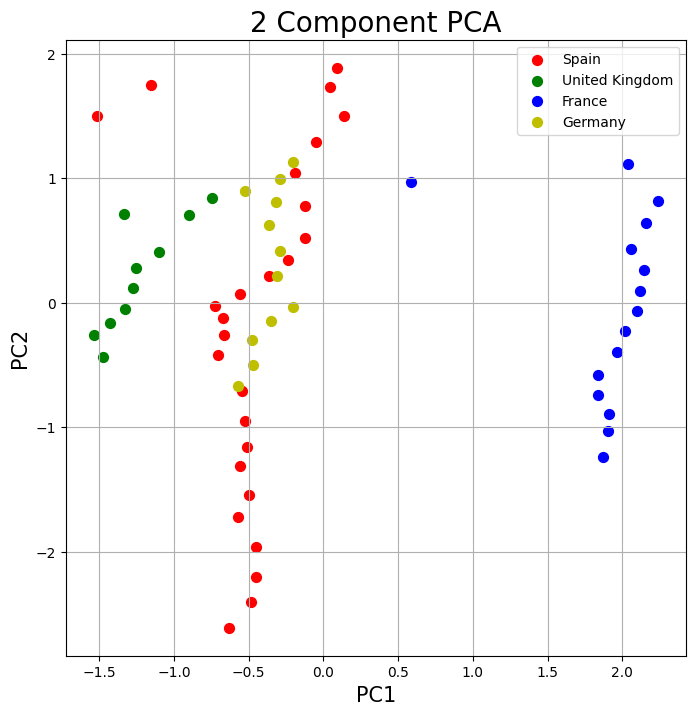

In [ ]:

# Inicializamos una lista con el nombre de los paises que vamos a analizar
countries_to_analyze = ['Spain', 'United Kingdom', 'France', 'Germany']

# Utilizamos la lista para crear una máscara booleana para filtrar solo estas entradas al obtener los datos
boolean_mask = df_tourist_and_employed.Entity.isin(countries_to_analyze)

# Obtengo un array con toda la información de las columnas (Años, Trabajo en hostelería y Turistas)
x_year_tourist_employed = df_tourist_and_employed[boolean_mask].iloc[:, 2:].values

# Obtengo todas las filas con los datos de la primera columna (Paises) de los paises seleccionados
y_country = df_tourist_and_employed[boolean_mask].iloc[:, 0].values

# Normalizamos los datos de turismo
scaler = StandardScaler()
x_year_tourist_employed_scaled = scaler.fit_transform(x_year_tourist_employed)

# Inicializamos PCA definiendo que queremos que nos deje solo 2 dimensiones (reduciremos una dimensión)
pca = PCA(n_components=2)
pc1_pc2_data = pca.fit_transform(x_year_tourist_employed_scaled)

# Creamos el dataframe con los datos obtenidos por PCA
df_pca = pd.DataFrame(data=pc1_pc2_data, columns=['PC1', 'PC2'])
df_pca['target'] = y_country

# Pintamos los datos en un gráfico con dos dimensiones
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_title('2 Component PCA', fontsize = 20)
targets = countries_to_analyze
colors = ['r', 'g', 'b', 'y']
for target, color in zip(targets,colors):
    indicesToKeep = df_pca['target'] == target
    ax.scatter(df_pca.loc[indicesToKeep, 'PC1']
               , df_pca.loc[indicesToKeep, 'PC2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

Una vez hecho el proceso, podemos ver que la evolución del turismo y trabajadores de hostelería a lo largo del tiempo. En el gráfico vemos como en España, Reino Unido y Alemania es similar, pero en Francia tiene un comportamiento diferente.

Con este gráfico también podemos ver algún punto en España y en Francia que podríamos estudiar más en detalle porque parecen outliers, intuyo que estos puntos reflejan el bajón visto en puntos anteriores por el Covid.

# 9.- Validación cruzada

En este punto vamos a utilizar la validación cruzada para verificar que el potencial modelo que entrenaríamos con nuestro dataset no está sobreajustado a estos datos y mostraría un comportamiento coherente con datos nuevos.

En este punto también voy a utilizar el dataframe que junta ambos datasets como en el punto anterior.

La validación cruzada se utiliza sobre todo para predecir una categoría en función de unos datos de entrada. En este caso, lo único que podemos obtener es el país en función de su turismo y trabajadores en hostelería por año. Probablemente no obtengamos resultados muy satisfactorios, porque aunque tengamos bastantes datos, también tenemos muchos paises, lo que nos deja unas pocas entradas por país y probablemente no haya suficiente información para realizar la predicción. También hay que destacar, que como hemos visto en el punto anterior, de los 4 paises que hemos obtenido para estudiar el comportamiento de la mayoría de ellos era similar. Esto nos podría dar una pista de que en el resto de paises los datos podrían seguir la misma tónica. Esto probablemente ocasionará que al no haber mucha diferencia entre un pais u otro tengamos unos resultados pobres, pues será facil que se confunda entre ellos.

In [ ]:
# Obtengo un array con toda la información de las columnas numéricas que voy a utilizar para predecir el pais
x = df_tourist_and_employed.iloc[:, 2:].values

# Obtengo todas las filas de los paises, etiqueta a predecir
y = df_tourist_and_employed.iloc[:, 0].values

# Inicializo el tipo de modelo que voy a utilizar (Arbol de decisión)
classifier = DecisionTreeClassifier()

# Se obtienen los resultados del entrenamiento dividiendo el conjunto de datos en 10 grupos iguales (Se entrena con 9 y validacon 1 repitiendo esto 10 veces)
scores = cross_val_score(classifier, x, y, cv=10)

# Recorremos los resultados y pintamos la precisión que ha tenido cada entrenamiento para
for i, score in enumerate(scores):
    print("Accuracy of fold %d: %.2f" % (i+1, score))

# Pintamos la media de la precisión obtenida
print("Mean Accuracy: %.2f%%" % (scores.mean()*100))

Accuracy of fold 1: 0.47
Accuracy of fold 2: 0.72
Accuracy of fold 3: 0.72
Accuracy of fold 4: 0.69
Accuracy of fold 5: 0.67
Accuracy of fold 6: 0.72
Accuracy of fold 7: 0.69
Accuracy of fold 8: 0.54
Accuracy of fold 9: 0.50
Accuracy of fold 10: 0.31
Mean Accuracy: 60.33%


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Una vez completado el análisis vemos que los resultados no son muy promentedores. Probablemente por lo que hemos indicado antes, se combina que hay muchas etiquetas diferentes (paises) con comportamientos similares y por cada etiqueta no hay muchas filas.

Esto también se debe a que el dataset no está realmente pensado para este tipo de entrenamientos.

Para hacer una última prueba con unos resultados más prometedores, podemos hacer validación cruzada solamente para las entradas de España y Francia, pues sabemos que su comportamiento era algo diferente como hemos visto en la reducción de datos, por lo que probablemente los resultados arrojados sean más prometedores (Aunque seguiremos teniendo el problema de que hay pocas entradas por pais).

In [ ]:
# Inicializamos una lista con el nombre de los paises que vamos a intentar predecir
countries_to_analyze = ['Spain', 'France']

# Utilizamos la lista para crear una máscara booleana para filtrar solo estas entradas al obtener los datos
boolean_mask = df_tourist_and_employed.Entity.isin(countries_to_analyze)

# Obtengo un array con toda la información de las columnas numéricas que voy a utilizar para predecir el pais
x = df_tourist_and_employed[boolean_mask].iloc[:, 2:].values

# Obtengo todas las filas de los paises, etiqueta a predecir
y = df_tourist_and_employed[boolean_mask].iloc[:, 0].values

# Inicializo el tipo de modelo que voy a utilizar (Arbol de decisión)
classifier = DecisionTreeClassifier()

# Se obtienen los resultados del entrenamiento dividiendo el conjunto de datos en 10 grupos iguales (Se entrena con 9 y validacon 1 repitiendo esto 10 veces)
scores = cross_val_score(classifier, x, y, cv=10)

# Recorremos los resultados y pintamos la precisión que ha tenido cada entrenamiento para
for i, score in enumerate(scores):
    print("Accuracy of fold %d: %.2f" % (i+1, score))

# Pintamos la media de la precisión obtenida
print("Mean Accuracy: %.2f%%" % (scores.mean()*100))

Accuracy of fold 1: 0.80
Accuracy of fold 2: 1.00
Accuracy of fold 3: 1.00
Accuracy of fold 4: 1.00
Accuracy of fold 5: 1.00
Accuracy of fold 6: 1.00
Accuracy of fold 7: 1.00
Accuracy of fold 8: 1.00
Accuracy of fold 9: 1.00
Accuracy of fold 10: 1.00
Mean Accuracy: 98.00%


Vemos como en efecto, utilizando solo las entradas de estos dos paises, los cuales tienen un comportamiento más distinguible, obtenemos unos resultados bastante más precisos. Aunque como he dicho antes, lo ideal sería tener un conjunto de datos mucho mayor por cada etiqueta (No era el mejor dataset para este tipo de pruebas).

# 10.- Testo de hipótesis

El testeo de hipótesis nos permite confirmar si un conjunto de datos nos da evidencias de un comportamiento definido para determinadas etiquetas, o simplemente esa muestra es un conjunto aleatorio que no representa la realidad. Esto se utiliza para no utilizar conjuntos muy grandes de datos cuando unos más pequeños ya representan la realidad y ahorrar tiempo y dinero en los entrenamientos.

En este caso yo voy a estudiar la hipótesis de que el número de turistas que llegan a un país está relacionado con el número de personas que trabajan en hostelería.

He buscado en la librería de scipy.stats que diferentes métodos tenía para probar la hipótesis, pues el utilizado en la teoría `ttest_ind` no creo que me sirviese para este caso. El que creo que era más correcto para estudiar la correlación era `pearsonr` pero puedo estar equivocado, ya que aun no hemos entrado en tanto detalle en el curso.

In [ ]:
# Obtengo las dos variables que voy a utilizar para estudiar su correlación
employment = df_tourist_and_employed['Employment (food and beverage serving activities) per 1000 people']
tourist = df_tourist_and_employed['Inbound arrivals (tourists)']

# Obtengo la correlación y el valor de P para la hipótesis utilizando pearsonr
corr, p = stats.pearsonr(employment, tourist)

# Muestro la correlación y el valor de P obtenidos del estudio de hipótesis
print("Correlación: ", corr)
print("P-value: ", p)


Correlación:  0.1231889542521256
P-value:  0.00014922256625714527


Una vez observamos los datos arrojados por el test podemos sacar conclusiones. Lo primero que podemos afirmar es que el valor de p es muy inferior a 0,05, por lo que podemos rechazar la hipótesis nula a favor de la hipótesis alternativa, es decir, si hay relación entre los datos. Pero si nos fijamos en el valor de correlación es muy bajo (0.12), esto nos indica que aunque los datos están correlados, la relación entre ambos es muy debil.

En resumen, el turismo y el empleo en hostelería están relacionados debilmente. Cuanto más turismo más crece el sector de la hostelería, pero no es el factor principal, influye, pero poco. Probablemente hay muchos más factores que no tenemos incluidos en nuestro dataset que afectarán de una manera más directa al número de trabajadores en hostelería.

# 11.- Detección de anomalías
En este punto vamos a detectar los posibles valores anómalos que haya en el conjunto de datos.

Voy a sacar los outliers de la relación entre turismo y empleados en hostelería así podremos analizar en dos dimensiones la dispersión en la gráfica de los puntos que obtengamos como outliers.


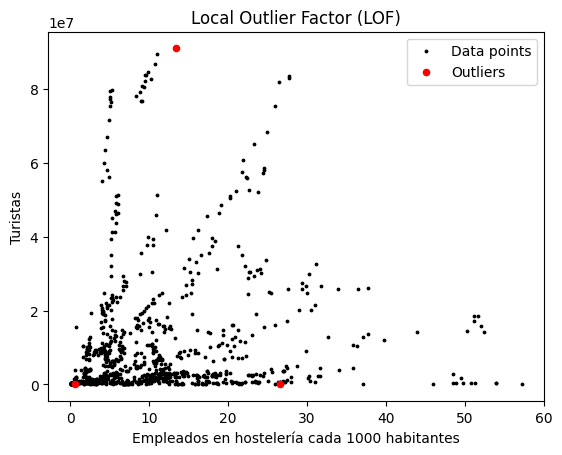

In [ ]:
X = df_tourist_and_employed.get(['Employment (food and beverage serving activities) per 1000 people', 'Inbound arrivals (tourists)']).values

lof = LocalOutlierFactor()
y_pred = lof.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], color='k', s=3, label='Data points')
plt.scatter(X[y_pred == -1, 0], X[y_pred == -1, 1], color='r', s=20, label='Outliers')
plt.xlabel('Empleados en hostelería cada 1000 habitantes')
plt.ylabel('Turistas')
plt.title("Local Outlier Factor (LOF)")
plt.legend()
plt.show()

Vemos que nos muestra 3 outliers con K = 20 (valor por defecto). Esto representa que hay 3 puntos que dada la densidad de puntos a su alrededor son anómalos. Cuando hacemos este análisis nos da pistas de datos fuera de lo común, y nos permite actuar eliminándo estas entradas o dándoles un valor medio, pero las acciones a tomar sobre el dataset dependerán del análisis de sus implicaciones.

He probado a hacer el análisis con diferentes valores para K y vemo que me detecta más o menos outliers, entiendo porque me varían, pero como aun estamos a inicio del curso, no tengo conocimientos sobre que valor correcto que debería darle a k para su correcto análisis.